In [1]:

# Importación de bibliotecas necesarias para el análisis de datos y modelado
import pandas as pd  # Biblioteca para manipulación y análisis de datos
import numpy as np  # Biblioteca para operaciones numéricas y matrices
import seaborn as sns  # Biblioteca para visualización de datos basada en matplotlib
import matplotlib.pyplot as plt  # Biblioteca para crear gráficos y visualizaciones
from sklearn.linear_model import LinearRegression  # Modelo de regresión lineal de scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Métricas de evaluación de modelos
from sklearn.model_selection import train_test_split  # Función para dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.ensemble import IsolationForest  # Algoritmo de detección de anomalías basado en árboles de decisión
from sklearn.preprocessing import StandardScaler  # Escalador estándar para normalizar características


In [2]:
# CARGAR Y PREPARAR LOS DATOS
# [VERDE] Cargar los datos desde un archivo CSV o base de datos.
data = pd.read_csv('energia.csv')

In [3]:
# [VERDE] Imputar valores faltantes con ceros.
data = data.fillna(0)

In [4]:
# Vista general de los datos
print("Vista general de los datos:")
display(data.head())

Vista general de los datos:


,ID DEPATAMENTO,DEPARTAMENTO,ID MUNICIPIO,MUNICIPIO,ID LOCALIDAD,LOCALIDAD,AÑO SERVICIO,MES SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA,POTENCIA MÁXIMA,DÍA DE DEMANDA MÁXIMA,FECHA DE DEMANDA MÁXIMA,PROMEDIO DIARIO EN HORAS
0,91,AMAZONAS,91001,LETICIA,91001000,LETICIA (LETICIA - AMAZONAS),2020,1,3930642,1251191,7768.76,lunes,01/27/2020 02:15:00 PM,24.00
1,91,AMAZONAS,91540,PUERTO NARIÑO,91540000,PUERTO NARIÑO (PUERTO NARIÑO - AMAZONAS),2020,1,103897,36304,227.04,miércoles,01/22/2020 07:15:00 PM,24.00
2,91,AMAZONAS,91798,TARAPACÁ (ANM),91798000,TARAPACÁ (TARAPACÁ (ANM) - AMAZONAS),2020,1,22864,9277,88.96,jueves,01/30/2020 07:30:00 PM,10.19
3,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873001,SAN ANTONIO DE PADUA (VIGÍA DEL FUERTE - ANTIO...,2020,1,5617,1381,53.66,jueves,01/23/2020 07:45:00 PM,4.13
4,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873002,VEGÁEZ (VIGÍA DEL FUERTE - ANTIOQUIA),2020,1,2217,539,39.07,miércoles,01/29/2020 07:45:00 PM,3.17


In [5]:
# Información general del dataset
print("\nInformación del dataset:")
data.info()


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3294 entries, 0 to 3293
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID DEPATAMENTO            3294 non-null   int64  
 1   DEPARTAMENTO              3294 non-null   object 
 2   ID MUNICIPIO              3294 non-null   int64  
 3   MUNICIPIO                 3294 non-null   object 
 4   ID LOCALIDAD              3294 non-null   int64  
 5   LOCALIDAD                 3294 non-null   object 
 6   AÑO SERVICIO              3294 non-null   int64  
 7   MES SERVICIO              3294 non-null   int64  
 8   ENERGÍA ACTIVA            3294 non-null   int64  
 9   ENERGÍA REACTIVA          3294 non-null   int64  
 10  POTENCIA MÁXIMA           3294 non-null   float64
 11  DÍA DE DEMANDA MÁXIMA     3294 non-null   object 
 12  FECHA DE DEMANDA MÁXIMA   3294 non-null   object 
 13  PROMEDIO DIARIO EN HORAS  3294 non-nu

In [6]:
## Análisis Exploratorio de Datos (EDA)

# Descripción estadística de las variables numéricas
print("\nDescripción estadística:")
display(data.describe())


Descripción estadística:


,ID DEPATAMENTO,ID MUNICIPIO,ID LOCALIDAD,AÑO SERVICIO,MES SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA,POTENCIA MÁXIMA,PROMEDIO DIARIO EN HORAS
count,3294.000000,3294.000000,3.294000e+03,3294.000000,3294.000000,3.294000e+03,3.294000e+03,3.294000e+03,3294.000000
mean,45.601700,46008.681542,4.600873e+07,2021.275956,6.053734,3.628131e+05,1.072491e+05,1.838501e+03,12.023604
std,29.164858,29131.144975,2.913113e+07,1.024474,3.460483,1.786971e+06,4.767422e+05,4.812798e+04,7.343238
min,5.000000,5873.000000,5.873000e+06,2020.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,19.000000,19809.000000,1.980903e+07,2020.000000,3.000000,5.402000e+03,2.113250e+03,3.476750e+01,6.300000
50%,27.000000,27800.000000,2.780000e+07,2021.000000,6.000000,1.336500e+04,5.625500e+03,7.590500e+01,8.540000
75%,52.000000,52835.000000,5.283522e+07,2022.000000,9.000000,8.397025e+04,3.080350e+04,2.238000e+02,19.275000
max,99.000000,99773.000000,9.977300e+07,2023.000000,12.000000,1.859779e+07,4.904871e+06,2.694319e+06,24.000000


In [7]:
# Identificar valores nulos
print(data.isnull().sum())

# Eliminar filas con valores nulos
data = data.dropna()

ID DEPATAMENTO              0
DEPARTAMENTO                0
ID MUNICIPIO                0
MUNICIPIO                   0
ID LOCALIDAD                0
LOCALIDAD                   0
AÑO SERVICIO                0
MES SERVICIO                0
ENERGÍA ACTIVA              0
ENERGÍA REACTIVA            0
POTENCIA MÁXIMA             0
DÍA DE DEMANDA MÁXIMA       0
FECHA DE DEMANDA MÁXIMA     0
PROMEDIO DIARIO EN HORAS    0
dtype: int64


In [8]:
# Eliminar filas duplicadas
data = data.drop_duplicates()

In [9]:
### Localidades con menor acceso energético

# Localidades con energía activa mínima
print("\nLocalidades con menor acceso energético (menor energía activa):")
min_energy_localities = data.nsmallest(5, 'ENERGÍA ACTIVA')[['DEPARTAMENTO', 'MUNICIPIO', 'LOCALIDAD', 'ENERGÍA ACTIVA']]
display(min_energy_localities)


Localidades con menor acceso energético (menor energía activa):


,DEPARTAMENTO,MUNICIPIO,LOCALIDAD,ENERGÍA ACTIVA
554,CAUCA,TIMBIQUÍ,SANTA ROSA DE SAIJA (TIMBIQUÍ - CAUCA),0
2058,NARIÑO,FRANCISCO PIZARRO,SAN PEDRO DEL VINO (FRANCISCO PIZARRO - NARIÑO),0
2555,CAUCA,LÓPEZ DE MICAY,DOS QUEBRADAS RÍO NAYA (LÓPEZ DE MICAY - CAUCA),0
2580,CHOCÓ,MEDIO ATRATO (BETÉ),SAN ROQUE (MEDIO ATRATO (BETÉ) - CHOCÓ),0
2844,CAUCA,LÓPEZ DE MICAY,DOS QUEBRADAS RÍO NAYA (LÓPEZ DE MICAY - CAUCA),0


In [10]:
# CLASIFICACIÓN DE VARIABLES
# [VERDE] Clasificar las variables según su tipo.
numerical_discrete = ['ID DEPATAMENTO', 'ID MUNICIPIO', 'ID LOCALIDAD', 'AÑO SERVICIO', 'MES SERVICIO']
numerical_continuous = ['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA', 'POTENCIA MÁXIMA', 'PROMEDIO DIARIO EN HORAS']
categorical = ['DEPARTAMENTO', 'MUNICIPIO', 'LOCALIDAD', 'DÍA DE DEMANDA MÁXIMA']

In [11]:
# PROCESAMIENTO DE VARIABLES NO NUMÉRICAS
# Verificar si existen columnas de fechas y procesarlas
if 'FEHCA DEMANDA MÁXIMA' in data.columns:
    data['FEHCA DEMANDA MÁXIMA'] = pd.to_datetime(data['FEHCA DEMANDA MÁXIMA'])
    data['AÑO'] = data['FEHCA DEMANDA MÁXIMA'].dt.year
    data['MES'] = data['FEHCA DEMANDA MÁXIMA'].dt.month
    data['DÍA'] = data['FEHCA DEMANDA MÁXIMA'].dt.day
    data['HORA'] = data['FEHCA DEMANDA MÁXIMA'].dt.hour
    data.drop('FEHCA DEMANDA MÁXIMA', axis=1, inplace=True)

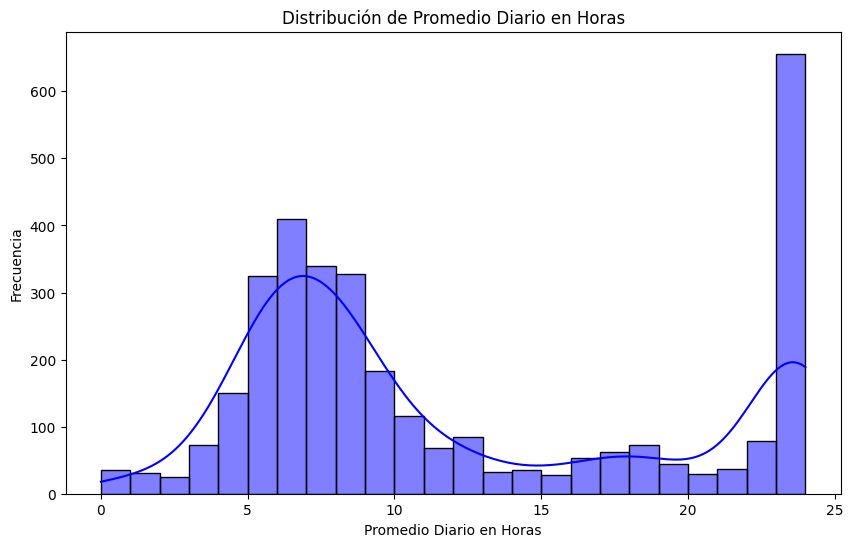

In [12]:
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# [VERDE] Histograma para la variable de interés (PROMEDIO DIARIO EN HORAS).
plt.figure(figsize=(10, 6))
sns.histplot(data['PROMEDIO DIARIO EN HORAS'], bins=24, kde=True, color='blue')
plt.title('Distribución de Promedio Diario en Horas')
plt.xlabel('Promedio Diario en Horas')
plt.ylabel('Frecuencia')
plt.show()

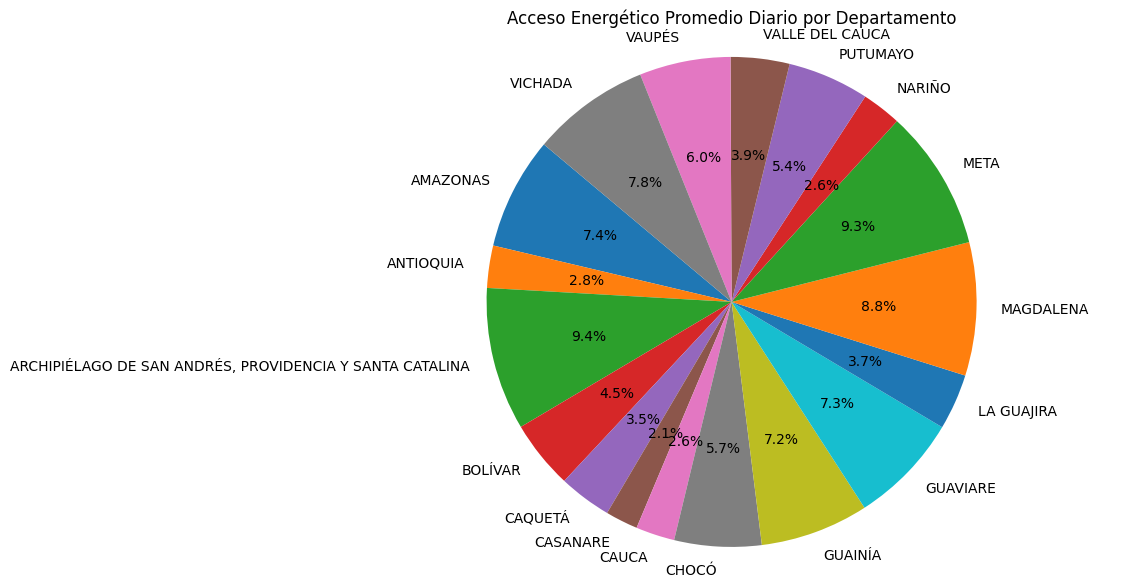

In [13]:
import pandas as pd 
import matplotlib.pyplot as plt
# Cargar el dataset
data = pd.read_csv('energia.csv')  # ruta real del archivo

# Agrupar los datos por departamento y calcular el promedio diario en horas
data_grouped = data.groupby('DEPARTAMENTO')['PROMEDIO DIARIO EN HORAS'].mean().reset_index()

# Crear la gráfica de torta
plt.figure(figsize=(10, 7))
plt.pie(data_grouped['PROMEDIO DIARIO EN HORAS'], labels=data_grouped['DEPARTAMENTO'], autopct='%1.1f%%', startangle=140)
plt.title('Acceso Energético Promedio Diario por Departamento')
plt.axis('equal')  # Para asegurar que el gráfico sea un círculo
plt.show()




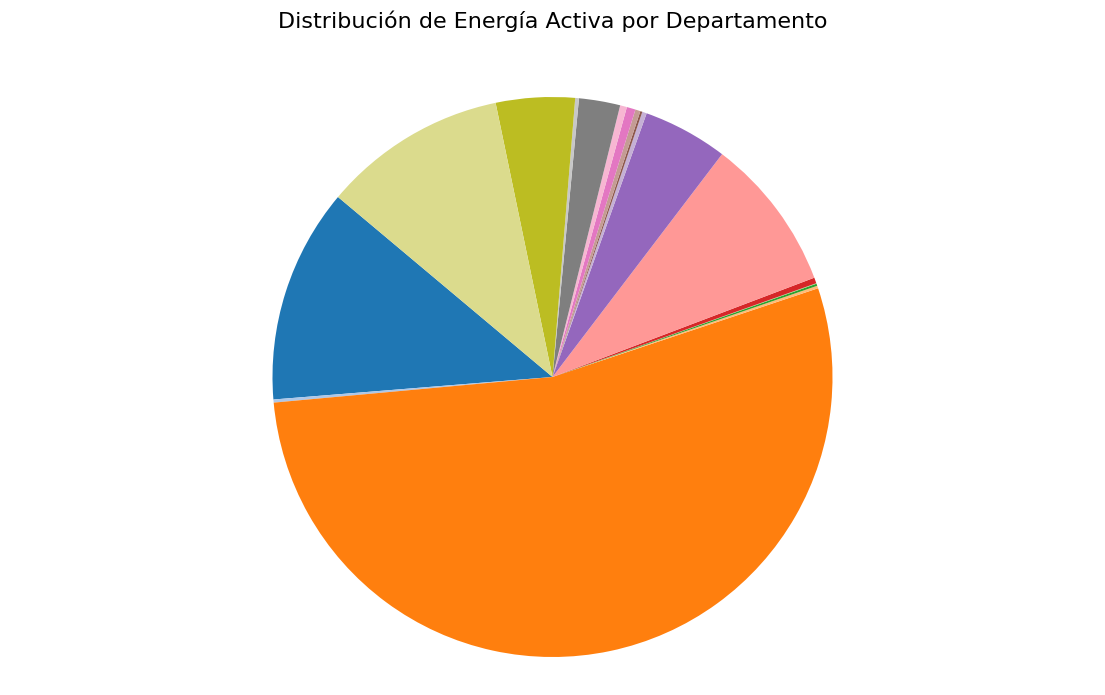

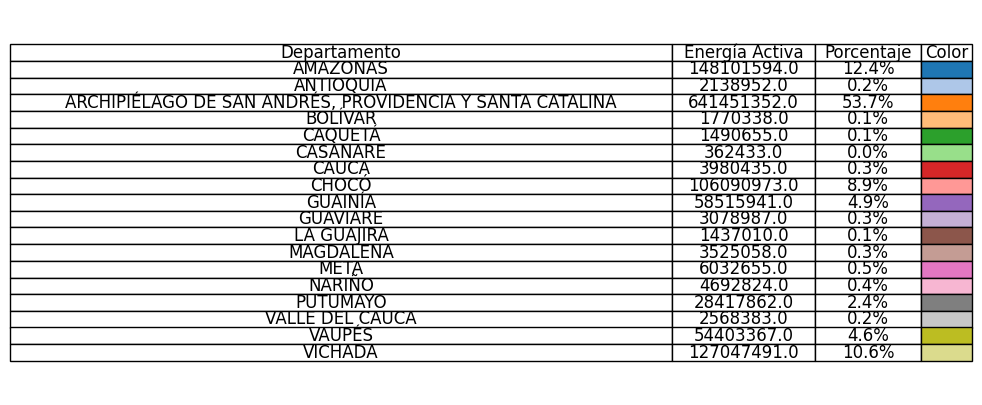

In [14]:
# Cargar el dataset
data = pd.read_csv('energia.csv')  #  ruta real del archivo

# Agrupar los datos por departamento y calcular la suma de la energía activa
data_grouped = data.groupby('DEPARTAMENTO')['ENERGÍA ACTIVA'].sum().reset_index()

# Calcular los porcentajes
data_grouped['Porcentaje'] = (data_grouped['ENERGÍA ACTIVA'] / data_grouped['ENERGÍA ACTIVA'].sum()) * 100

# Crear la gráfica de torta
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.tab20.colors  # Paleta de colores para los sectores
wedges, texts, autotexts = ax.pie(
    data_grouped['ENERGÍA ACTIVA'], 
    autopct='',  # Incluir los porcentajes directamente
    startangle=140, 
    colors=colors[:len(data_grouped)]
)

# Configurar el título y estilo del gráfico
ax.set_title('Distribución de Energía Activa por Departamento', fontsize=16, pad=30)
ax.axis('equal')  # Mantener la proporción circular

# Crear una tabla con nombres de departamentos, colores y porcentajes
table_data = [[dep, f'{data_grouped["ENERGÍA ACTIVA"][i]:.1f}', f'{data_grouped["Porcentaje"][i]:.1f}%', ' '] for i, dep in enumerate(data_grouped['DEPARTAMENTO'])]
table_colors = [colors[i] for i in range(len(data_grouped))]

fig, ax_table = plt.subplots(figsize=(10, 5))
ax_table.axis('tight')
ax_table.axis('off')

table = ax_table.table(
    cellText=table_data,
    colLabels=['Departamento', 'Energía Activa', 'Porcentaje', 'Color'],
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Aplicar colores de fondo para cada fila
for i, key in enumerate(table.get_celld()):
    if key[0] > 0:  # Saltar encabezados
        table[(key[0], 3)].set_facecolor(table_colors[key[0] - 1])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width([0, 1, 2, 3])  # Ajustar el tamaño de las columnas

plt.show()


In [15]:

#IDENTIFICAR LOCALIDADES CON MENOR ACCESO ENERGÉTICO
#Filtro de localidades con menor acceso (promedio bajo).
low_access_threshold = data['PROMEDIO DIARIO EN HORAS'].quantile(0.1)
low_access_localities = data[data['PROMEDIO DIARIO EN HORAS'] <= low_access_threshold]
print("Localidades con menor acceso energético:")
print(low_access_localities)

Localidades con menor acceso energético:
      ID DEPATAMENTO DEPARTAMENTO  ID MUNICIPIO             MUNICIPIO  \
3                  5    ANTIOQUIA          5873      VIGÍA DEL FUERTE   
4                  5    ANTIOQUIA          5873      VIGÍA DEL FUERTE   
14                19        CAUCA         19418        LÓPEZ DE MICAY   
15                19        CAUCA         19418        LÓPEZ DE MICAY   
17                19        CAUCA         19418        LÓPEZ DE MICAY   
...              ...          ...           ...                   ...   
3253              27        CHOCÓ         27077  BAJO BAUDÓ (PIZARRO)   
3255              27        CHOCÓ         27077  BAJO BAUDÓ (PIZARRO)   
3257              27        CHOCÓ         27077  BAJO BAUDÓ (PIZARRO)   
3278              52       NARIÑO         52427                 MAGÜÍ   
3279              52       NARIÑO         52427                 MAGÜÍ   

      ID LOCALIDAD                                          LOCALIDAD  \
3        

In [16]:
# Análisis descriptivo para estas localidades.
print("Estadísticas descriptivas para localidades con menor acceso energético:")
print(low_access_localities.describe())

Estadísticas descriptivas para localidades con menor acceso energético:
       ID DEPATAMENTO  ID MUNICIPIO  ID LOCALIDAD  AÑO SERVICIO  MES SERVICIO  \
count      335.000000    335.000000  3.350000e+02    335.000000    335.000000   
mean        31.704478  32184.540299  3.218465e+07   2021.316418      5.289552   
std         19.082373  19065.775205  1.906580e+07      1.169036      3.407861   
min          5.000000   5873.000000  5.873001e+06   2020.000000      1.000000   
25%         19.000000  19418.000000  1.941801e+07   2020.000000      2.000000   
50%         27.000000  27077.000000  2.707703e+07   2021.000000      5.000000   
75%         52.000000  52427.000000  5.242701e+07   2022.000000      8.000000   
max         97.000000  97161.000000  9.716100e+07   2023.000000     12.000000   

       ENERGÍA ACTIVA  ENERGÍA REACTIVA  POTENCIA MÁXIMA  \
count    3.350000e+02      3.350000e+02       335.000000   
mean     2.453785e+04      7.952388e+03        90.167731   
std      2.631385e

In [17]:
# PREPARACIÓN DE DATOS PARA MODELADO
# Codificar variables categóricas.
data_encoded = pd.get_dummies(data, columns=categorical, drop_first=True)

In [18]:
# Separar las características y la variable objetivo.
X = data_encoded.drop('PROMEDIO DIARIO EN HORAS', axis=1)  # Cambiado de 'ENERGÍA ACTIVA'
y = data_encoded['PROMEDIO DIARIO EN HORAS']  # Cambiado de 'ENERGÍA ACTIVA'

In [19]:
#Dividir en conjunto de entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Asegurar que X_train y X_test tengan las mismas columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
# Verificar columnas no numéricas
print("Tipos de datos en X_train antes de procesar:")
print(X_train.dtypes)

Tipos de datos en X_train antes de procesar:
ID DEPATAMENTO                     int64
ID MUNICIPIO                       int64
ID LOCALIDAD                       int64
AÑO SERVICIO                       int64
MES SERVICIO                       int64
                                   ...  
DÍA DE DEMANDA MÁXIMA_lunes         bool
DÍA DE DEMANDA MÁXIMA_martes        bool
DÍA DE DEMANDA MÁXIMA_miércoles     bool
DÍA DE DEMANDA MÁXIMA_sábado        bool
DÍA DE DEMANDA MÁXIMA_viernes       bool
Length: 215, dtype: object


In [21]:
# Convertir columnas de texto o categorías a formato numérico
if 'FEHCA DEMANDA MÁXIMA' in X_train.columns:
    # Convertir la columna 'fecha y hora' a tipo datetime
    X_train['FEHCA DEMANDA MÁXIMA'] = pd.to_datetime(X_train['FEHCA DEMANDA MÁXIMA'])
    X_train['año'] = X_train['FEHCA DEMANDA MÁXIMA'].dt.year
    X_train['mes'] = X_train['FEHCA DEMANDA MÁXIMA'].dt.month
    X_train['día'] = X_train['FEHCA DEMANDA MÁXIMA'].dt.day
    X_train['hora'] = X_train['FEHCA DEMANDA MÁXIMA'].dt.hour
    X_train.drop('FEHCA DEMANDA MÁXIMA', axis=1, inplace=True)  # Eliminar columna original

In [22]:
# Convertir columnas categóricas en variables dummy
categorical_columns = X_train.select_dtypes(include=['object']).columns
if len(categorical_columns) > 0:
    X_train = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True)

In [23]:
# Asegurar que ambas matrices tengan las mismas columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [24]:
# Verificar que todos los datos son numéricos
print("Tipos de datos en X_train después de procesar:")
print(X_train.dtypes)

Tipos de datos en X_train después de procesar:
ID DEPATAMENTO                                    int64
ID MUNICIPIO                                      int64
ID LOCALIDAD                                      int64
AÑO SERVICIO                                      int64
MES SERVICIO                                      int64
                                                  ...  
FECHA DE DEMANDA MÁXIMA_12/31/2022 06:30:00 PM     bool
FECHA DE DEMANDA MÁXIMA_12/31/2022 07:00:00 PM     bool
FECHA DE DEMANDA MÁXIMA_12/31/2022 07:15:00 PM     bool
FECHA DE DEMANDA MÁXIMA_12/31/2022 07:30:00 PM     bool
FECHA DE DEMANDA MÁXIMA_12/31/2022 07:45:00 PM     bool
Length: 2652, dtype: object


In [25]:
# Aplicar Isolation Forest
iso = IsolationForest(contamination=0.01)
outliers = iso.fit_predict(X_train)

In [26]:
# Filtrar datos no atípicos
X_train = X_train[outliers == 1]
y_train = y_train[outliers == 1]

In [27]:
# Eliminar valores atípicos usando Isolation Forest.
iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(X_train)
X_train = X_train[outliers == 1]
y_train = y_train[outliers == 1]

In [28]:
# Escalar los datos.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# MODELADO Y EVALUACIÓN
# Entrenar un modelo de regresión lineal.
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Realizar predicciones.
y_pred = model.predict(X_test_scaled)


Evaluación del Modelo:
Error Absoluto Medio (MAE): 0.70
Raíz del Error Cuadrático Medio (RMSE): 1.08


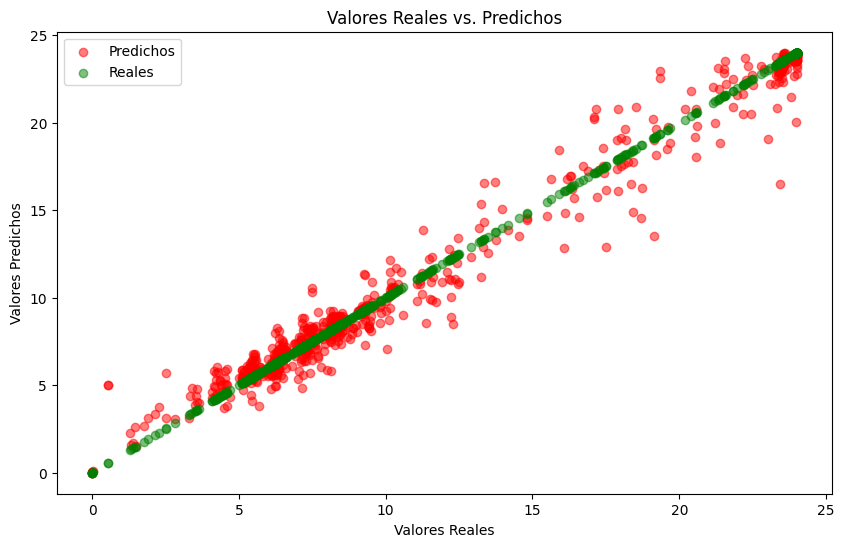

In [31]:
# Importar bibliotecas necesarias
import pandas as pd  # Para manipulación y análisis de datos
import numpy as np  # Para operaciones numéricas
from sklearn.ensemble import RandomForestRegressor  # Para el modelo de Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Para evaluar el modelo
from sklearn.model_selection import train_test_split  # Para dividir el conjunto de datos en entrenamiento y prueba
import matplotlib.pyplot as plt  # Para visualización de datos

#RANDOMFOREST
# Cargar el dataset
data = pd.read_csv('energia.csv')  # Asegúrate de cambiar 'energia.csv' por la ruta real de tu archivo

# Seleccionar las características y la variable objetivo
X = data[['ENERGÍA ACTIVA', 'POTENCIA MÁXIMA', 'ENERGÍA ACTIVA']]
y = data['PROMEDIO DIARIO EN HORAS']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo de Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nEvaluación del Modelo:")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# Comparar valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, c='red', label='Predichos')
plt.scatter(y_test, y_test, alpha=0.5, c='green', label='Reales')
plt.title('Valores Reales vs. Predichos')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.legend()
plt.show()



Evaluación del Modelo:
Error Absoluto Medio (MAE): 5.93
Raíz del Error Cuadrático Medio (RMSE): 6.77


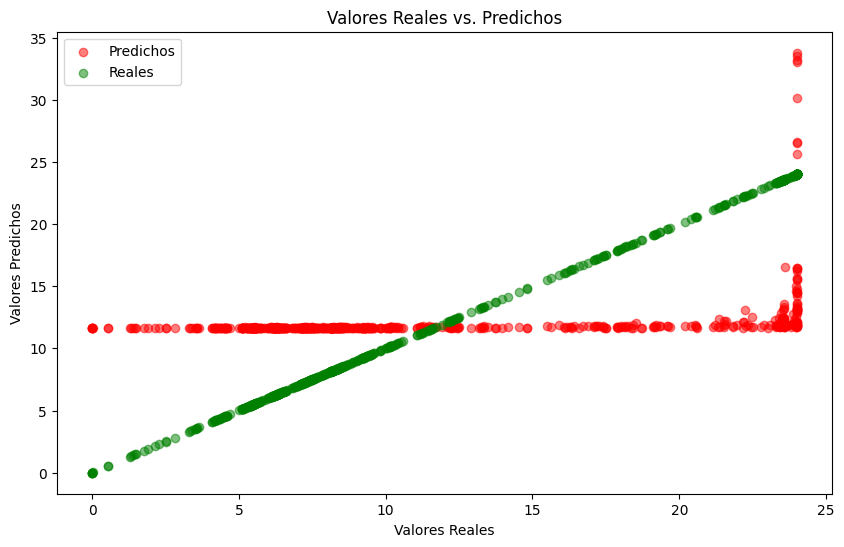

In [32]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt

# Cargar el dataset
data = pd.read_csv('energia.csv')  # ruta real del archivo

# Seleccionar las características y la variable objetivo
X = data[['ENERGÍA ACTIVA', 'POTENCIA MÁXIMA', 'ENERGÍA ACTIVA']]
y = data['PROMEDIO DIARIO EN HORAS']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nEvaluación del Modelo:")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# Comparar valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, c='red', label='Predichos')
plt.scatter(y_test, y_test, alpha=0.5, c='green', label='Reales')
plt.title('Valores Reales vs. Predichos')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.legend()
plt.show()


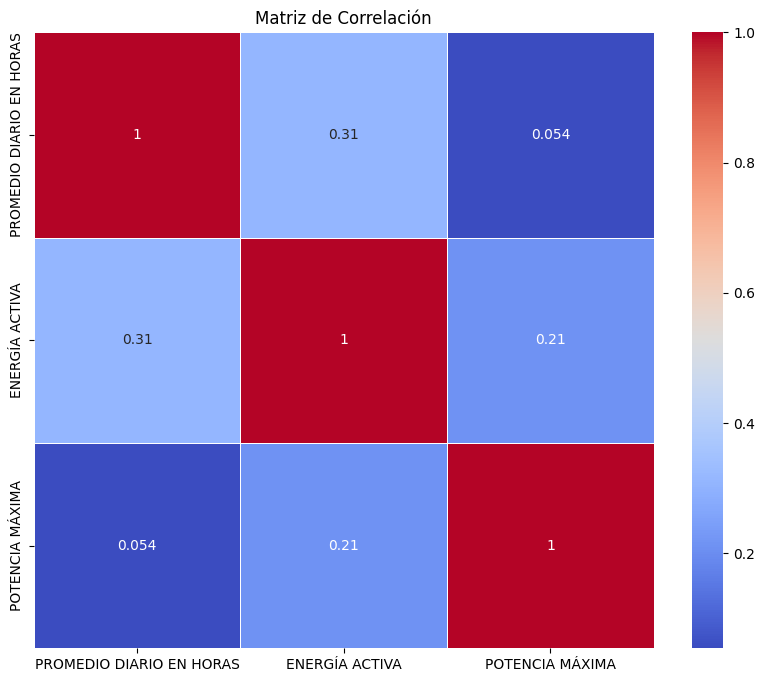

In [33]:
# Cargar el dataset
data = pd.read_csv('energia.csv')  #  ruta real del archivo

# Seleccionar las columnas relevantes
variables = ['PROMEDIO DIARIO EN HORAS', 'ENERGÍA ACTIVA', 'POTENCIA MÁXIMA']

# Crear la matriz de correlación
correlation_matrix = data[variables].corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()


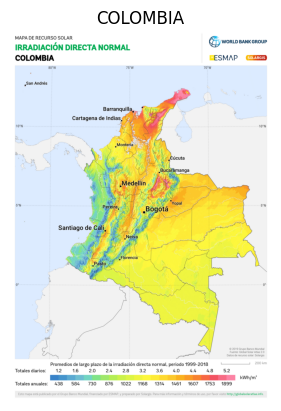

In [34]:
from PIL import Image
import matplotlib.pyplot as plt

# Cargar la imagen
image_path = 'ENERGIA.tif'  #  'ruta_a_tu_imagen.tif'.  ruta real del archivo de imagen
image = Image.open(image_path)

# Mostrar la imagen
plt.imshow(image)
plt.axis('off')  # Ocultar los ejes
plt.title('COLOMBIA')
plt.show()


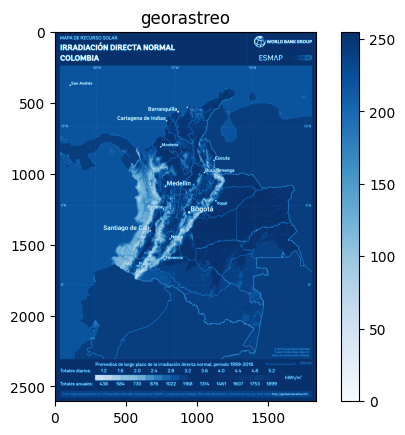

In [47]:
import rasterio
import pandas as pd
import warnings # Biblioteca para manejar avisos.

warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
with rasterio.open('ENERGIA.tif') as src:
    # Access raster data and metadata
    solar_raster_data = src.read(1)  # Read the first band, change the band number as needed
    solar_metadata = src.meta
import matplotlib.pyplot as plt

# Display the GeoRaster
plt.imshow(solar_raster_data, cmap='Blues')
plt.colorbar()
plt.title('georastreo')
plt.show()

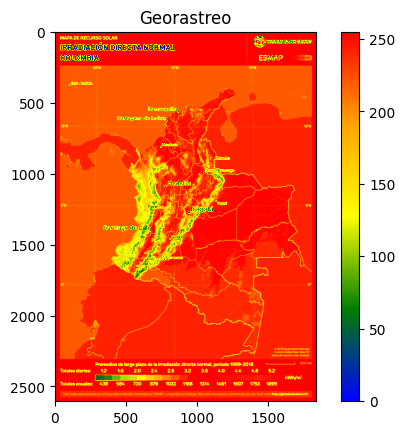

In [36]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Definir una paleta de colores continua personalizada
colors = ['blue', 'green', 'yellow', 'orange', 'red']
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

# Cargar el dataset
with rasterio.open('ENERGIA.tif') as src:
    # Acceder a los datos y metadatos del raster
    solar_raster_data = src.read(1)  # Leer la primera banda, cambia el número de banda según sea necesario
    solar_metadata = src.meta

# Mostrar el GeoRaster con la paleta de colores personalizada
plt.imshow(solar_raster_data, cmap=cmap)
plt.colorbar()
plt.title('Georastreo')
plt.show()



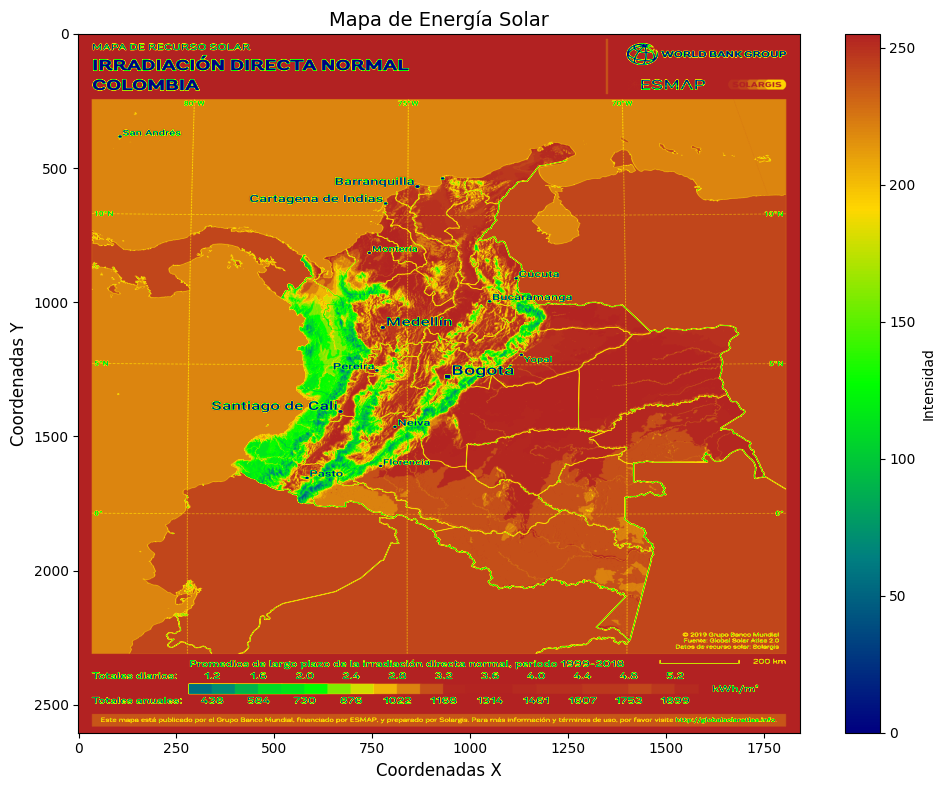

In [46]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import rasterio
import warnings # Biblioteca para manejar avisos.

warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
# Cargar el dataset
data = pd.read_csv('energia.csv')  # Asegúrate de cambiar 'energia.csv' por la ruta real de tu archivo

# Definir una paleta de colores continua personalizada con mayor contraste
colors = ['navy', 'teal', 'lime', 'gold', 'firebrick']
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

# Cargar el GeoRaster
with rasterio.open('ENERGIA.tif') as src:
    solar_raster_data = src.read(1)  # Leer la primera banda
    solar_metadata = src.meta

# Mostrar el GeoRaster con la paleta de colores personalizada
plt.figure(figsize=(10, 8))  # Ajustar el tamaño del gráfico
plt.imshow(solar_raster_data, cmap=cmap, aspect='auto')
plt.colorbar(label='Intensidad')  # Agregar etiqueta a la barra de colores
plt.title('Mapa de Energía Solar', fontsize=14, color='black')  # Título en negro
plt.xlabel('Coordenadas X', fontsize=12, color='black')  # Etiqueta del eje X
plt.ylabel('Coordenadas Y', fontsize=12, color='black')  # Etiqueta del eje Y
# Agregar nombres de los departamentos en el mapa
plt.tight_layout()  # Mejorar la disposición gráfica
plt.show()

